In [1]:
%cd /home/govind/gov_semproject/GridCellsCopy

/home/govind/gov_semproject/GridCellsCopy


In [80]:
import numpy as np
import matplotlib.pyplot as plt
import analysis_utils as a_utils
import sim_utils as s_utils
import g_utils
import seaborn as sns
import pandas as pd
from network_configs.instrumentations.trajectory1D import Trajectory1D


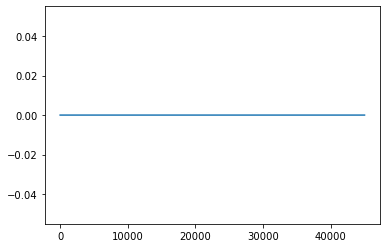

In [23]:
dc_theta = s_utils.load_data(sim_id='IA-3',sim_num=0,data_id="intrnrn_theta_dc")
plt.plot(np.linspace(0,len(dc_theta),len(dc_theta)),dc_theta)
plt.show()

Hallelujah
Stellate File Path :  data/IA-2/stell_spks_IA-2.hdf5
Interneuron File Path :  data/IA-2/intrnrn_spks_IA-2.hdf5


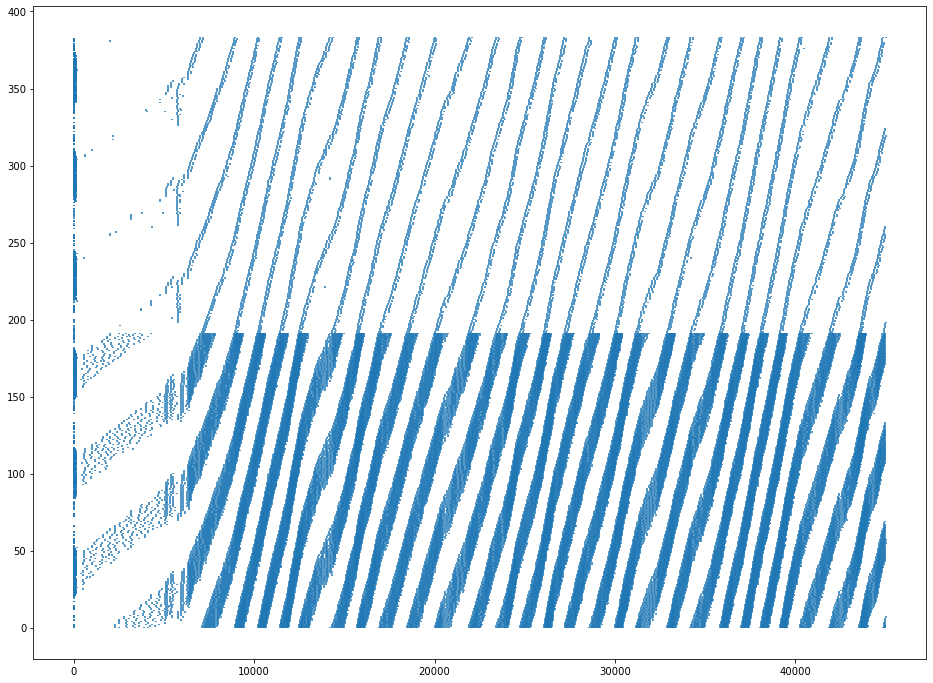

In [19]:
stell,_ = s_utils.load_spikes(sim_id='IA-2',sim_num=0)
plt.figure(figsize=(16,12))
plt.eventplot(stell)
plt.show()

NameError: name 'network_configs' is not defined

In [34]:
def circular_error(var1,var2):

    """Calculate the circular error between two angles.

    Parameters:
        var1 (float or array-like): The first angle in radians.
        var2 (float or array-like): The second angle in radians.
    Returns:
        numpy.ndarray: The minimum absolute difference between the angles
    """
    circum = 2*np.pi
    return np.abs(np.min(np.vstack((np.abs(var1-var2),circum-np.abs(var1-var2))),axis=0))

In [38]:
def abs_error(arr1,arr2):

    return np.sum(np.abs(arr1-arr2))

def total_error(sim_id,num_trials,sim_dur):
    """
    Mean and standard deviation of decoding error for a single simulation ID
    """
    erray = []
    params = s_utils.load_sim_params(sim_id=sim_id)["0"]
    traj = Trajectory1D(params=params,save_mem=False)
    pos_input,_,_ = g_utils.posn_vel_input(sim_id=sim_id,sim_dur=sim_dur,n_trials=num_trials,sim_num=0)
    for n in range(num_trials):
        stell_spks,_ = s_utils.load_spikes(sim_id=sim_id,sim_num=n)
        decoded_pos = a_utils.decode_pos(stell_spikes_l=stell_spks,win_size=40,t_start=int(traj.init_allothetic_dur),params=params)
    
        erray.append(np.sum(circular_error(decoded_pos[1:],pos_input[:-1])))

    dev = np.sqrt(np.var(erray))
    mean = np.mean(erray)

    return mean, dev

sample_mean,sample_std = total_error(sim_id = '1e3',num_trials=5,sim_dur=45000)

print(sample_mean,sample_std)



    

[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
Hallelujah
Stellate File Path :  data/1e3/stell_spks_1e3.hdf5
Interneuron File Path :  data/1e3/intrnrn_spks_1e3.hdf5
Hallelujah
Stellate File Path :  data/1e3/stell_spks_1e3.hdf5
Interneuron File Path :  data/1e3/intrnrn_spks_1e3.hdf5
Hallelujah
Stellate File Path :  data/1e3/stell_spks_1e3.hdf5
Interneuron File Path :  data/1e3/intrnrn_spks_1e3.hdf5
Hallelujah
Stellate File Path :  data/1e3/stell_spks_1e3.hdf5
Interneuron File Path :  data/1e3/intrnrn_spks_1e3.hdf5
Hallelujah
Stellate File Path :  data/1e3/stell_spks_1e3.hdf5
Interneuron File Path :  data/1e3/intrnrn_spks_1e3.hdf5
71915.0018197745 2351.4366713436407


In [92]:
plt.rcParams["font.family"] = "Arial"
plt.figure(figsize=(12,6))
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 12,
    "axes.titlesize": 18,
    "figure.titlesize": 20,
    "lines.linewidth": 2.0,
})

<Figure size 864x432 with 0 Axes>

[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
Hallelujah
Stellate File Path :  data/control3/stell_spks_control3.hdf5
Interneuron File Path :  data/control3/intrnrn_spks_control3.hdf5
Hallelujah
Stellate File Path :  data/control3/stell_spks_control3.hdf5
Interneuron File Path :  data/control3/intrnrn_spks_control3.hdf5
Hallelujah
Stellate File Path :  data/control3/stell_spks_control3.hdf5
Interneuron File Path :  data/control3/intrnrn_spks_control3.hdf5
Hallelujah
Stellate File Path :  data/control3/stell_spks_control3.hdf5
Interneuron File Path :  data/control3/intrnrn_spks_control3.hdf5
Hallelujah
Stellate File Path :  data/control3/stell_spks_control3.hdf5
Interneuron File Path :  data/control3/intrnrn_spks_control3.hdf5
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
[2.49986607e-11 4.9

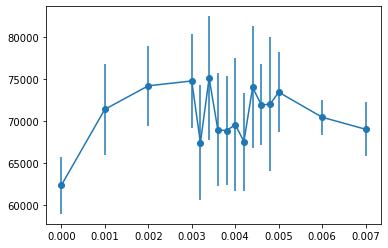

In [39]:
amp_list = [0,1e-3,2e-3,3e-3,3.2e-3,3.4e-3,3.6e-3,3.8e-3,4e-3,4.2e-3,4.4e-3,4.6e-3,4.8e-3,5e-3,6e-3,7e-3]

sim_id_list = ['control3','1e3_2','2e3_2','3e3_2','32e3_2','34e3_2','36e3_2','38e3_2','4e3_2','42e3_2','44e3_2','46e3_2','48e3_2','5e3_2','6e3_2','7e3_2']

mean_list,std_list = [],[]
for id in sim_id_list:
    mean,std = total_error(sim_id=id,sim_dur=45000,num_trials=5)
    mean_list.append(mean)
    std_list.append(std)



In [94]:
amp_3_list = [0,1e-3,2e-3,3e-3,3.2e-3,3.4e-3,3.6e-3,3.8e-3,4e-3,4.2e-3,4.4e-3,4.6e-3,4.8e-3,5e-3,6e-3,7e-3]
mean_3_list = mean_list
std_3_list = std_list

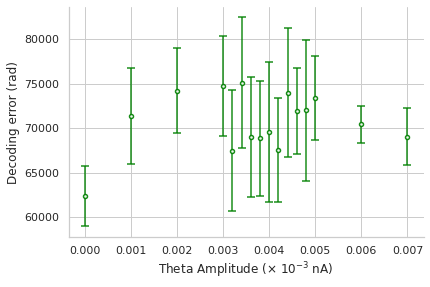

In [101]:


color = sns.color_palette("deep")[0]

plt.errorbar(
    amp_3_list, mean_3_list,
    yerr=std_3_list,
    fmt="o",                   # ensures error bars and markers match
    markersize=4,
    capsize=4,
    elinewidth=1.5,
    color='green',
    markerfacecolor="white",
    markeredgecolor='green',
    markeredgewidth=1.5,
    alpha=0.9,
)

plt.ylabel("Decoding error (rad)")
plt.xlabel("Theta Amplitude (× $10^{-3}$ nA)")

sns.despine()
plt.tight_layout()
plt.show()


In [44]:
amp_list = [0,1e-3,2e-3,3e-3,4e-3,4.4e-3,4.6e-3,4.8e-3,5e-3,5.2e-3,5.4e-3,5.6e-3,6e-3,7e-3]

sim_id_list = ['control1','1e3','2e3','3e3','4e3','44e3','46e3','48e3','5e3','52e3','54e3','56e3','6e3','7e3']

mean_1_list,std_1_list = [],[]
for id in sim_id_list:
    mean,std = total_error(sim_id=id,sim_dur=45000,num_trials=5)
    mean_1_list.append(mean)
    std_1_list.append(std)

[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
Hallelujah
Stellate File Path :  data/control1/stell_spks_control1.hdf5
Interneuron File Path :  data/control1/intrnrn_spks_control1.hdf5
Hallelujah
Stellate File Path :  data/control1/stell_spks_control1.hdf5
Interneuron File Path :  data/control1/intrnrn_spks_control1.hdf5
Hallelujah
Stellate File Path :  data/control1/stell_spks_control1.hdf5
Interneuron File Path :  data/control1/intrnrn_spks_control1.hdf5
Hallelujah
Stellate File Path :  data/control1/stell_spks_control1.hdf5
Interneuron File Path :  data/control1/intrnrn_spks_control1.hdf5
Hallelujah
Stellate File Path :  data/control1/stell_spks_control1.hdf5
Interneuron File Path :  data/control1/intrnrn_spks_control1.hdf5
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
[2.49986607e-11 4.9

14


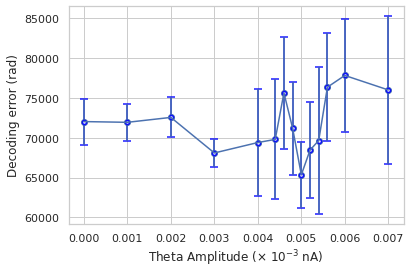

In [130]:
print(len(mean_1_list))

color = sns.color_palette("deep")[0]

plt.errorbar(
    amp_list, mean_1_list,
    yerr=std_1_list,
    fmt="o",                   # ensures error bars and markers match
    markersize=4,
    capsize=4,
    elinewidth=1.5,
    color='blue',
    markerfacecolor="white",
    markeredgecolor='blue',
    markeredgewidth=1.5,
    alpha=0.9,
)

plt.ylabel("Decoding error (rad)")
plt.xlabel("Theta Amplitude (× $10^{-3}$ nA)")

plt.scatter(amp_list,mean_1_list)
plt.errorbar(amp_list,mean_1_list,yerr=std_1_list)
plt.show()

In [55]:
amp_2_list = [0,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3]

sim_id_list = ['control2','1e3_1','2e3_1','3e3_1','4e3_1','5e3_1','6e3_1','7e3_1']

mean_2_list,std_2_list = [],[]
for id in sim_id_list:
    mean,std = total_error(sim_id=id,sim_dur=45000,num_trials=5)
    mean_2_list.append(mean)
    std_2_list.append(std)

[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
Hallelujah
Stellate File Path :  data/control2/stell_spks_control2.hdf5
Interneuron File Path :  data/control2/intrnrn_spks_control2.hdf5
Hallelujah
Stellate File Path :  data/control2/stell_spks_control2.hdf5
Interneuron File Path :  data/control2/intrnrn_spks_control2.hdf5
Hallelujah
Stellate File Path :  data/control2/stell_spks_control2.hdf5
Interneuron File Path :  data/control2/intrnrn_spks_control2.hdf5
Hallelujah
Stellate File Path :  data/control2/stell_spks_control2.hdf5
Interneuron File Path :  data/control2/intrnrn_spks_control2.hdf5
Hallelujah
Stellate File Path :  data/control2/stell_spks_control2.hdf5
Interneuron File Path :  data/control2/intrnrn_spks_control2.hdf5
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
[2.49986607e-11 4.9

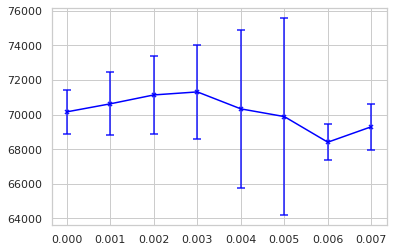

In [132]:
color = sns.color_palette("deep")[0]

plt.errorbar(
    amp_2_list, mean_2_list,
    yerr=std_2_list,
    fmt="x",                   # ensures error bars and markers match
    markersize=4,
    capsize=4,
    elinewidth=1.5,
    color='blue',
    markerfacecolor="white",
    markeredgecolor='blue',
    markeredgewidth=1.5,
    alpha=0.9,
)


plt.plot(amp_2_list,mean_2_list,color='blue')
#plt.errorbar(amp_2_list,mean_2_list,yerr=std_2_list)
plt.show()

In [58]:
amp_4_list = [0,1e-3,2e-3,3e-3,4e-3,5e-3,6e-3,7e-3]

sim_id_list = ['1e3_3','2e3_3','3e3_3','4e3_3','5e3_3','6e3_3','7e3_3']

mean_4_list,std_4_list = [],[]
for id in sim_id_list:
    mean,std = total_error(sim_id=id,sim_dur=45000,num_trials=5)
    mean_4_list.append(mean)
    std_4_list.append(std)

[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
Hallelujah
Stellate File Path :  data/1e3_3/stell_spks_1e3_3.hdf5
Interneuron File Path :  data/1e3_3/intrnrn_spks_1e3_3.hdf5
Hallelujah
Stellate File Path :  data/1e3_3/stell_spks_1e3_3.hdf5
Interneuron File Path :  data/1e3_3/intrnrn_spks_1e3_3.hdf5
Hallelujah
Stellate File Path :  data/1e3_3/stell_spks_1e3_3.hdf5
Interneuron File Path :  data/1e3_3/intrnrn_spks_1e3_3.hdf5
Hallelujah
Stellate File Path :  data/1e3_3/stell_spks_1e3_3.hdf5
Interneuron File Path :  data/1e3_3/intrnrn_spks_1e3_3.hdf5
Hallelujah
Stellate File Path :  data/1e3_3/stell_spks_1e3_3.hdf5
Interneuron File Path :  data/1e3_3/intrnrn_spks_1e3_3.hdf5
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-0

In [82]:
import matplotlib
print(matplotlib.rcParams["font.family"])

['Helvetica']


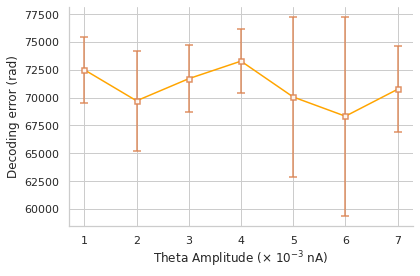

In [128]:
sns.set_theme(style="whitegrid")


amp_4_list = [1,2,3,4,5,6,7]

# Choose a soft, modern blue
color = sns.color_palette("deep")[1]
plt.plot(amp_4_list,mean_4_list,color='orange')
plt.errorbar(
    amp_4_list, mean_4_list,
    yerr=std_4_list,
    fmt="s",                   # ensures error bars and markers match
    markersize=5,
    capsize=4,
    elinewidth=1.5,
    color=color,
    markerfacecolor="white",
    markeredgecolor=color,
    markeredgewidth=1.5,
    alpha=0.9,
)

plt.ylabel("Decoding error (rad)")
plt.xlabel("Theta Amplitude (× $10^{-3}$ nA)")

sns.despine()
plt.tight_layout()
plt.show()

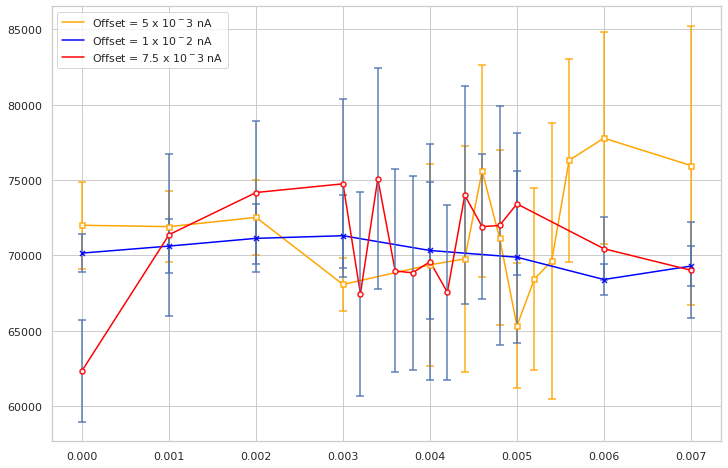

In [138]:
#combining all data
plt.figure(figsize=(12,8))
plt.plot(amp_list,mean_1_list,color='orange',label='Offset = 5 x $10^-3$ nA')
plt.errorbar(
    amp_list, mean_1_list,
    yerr=std_1_list,
    fmt="s",                   # ensures error bars and markers match
    markersize=5,
    capsize=4,
    elinewidth=1.5,
    color='orange',
    markerfacecolor="white",
    markeredgecolor='orange',
    markeredgewidth=1.5,
    alpha=0.9,
)

plt.plot(amp_2_list,mean_2_list,color='blue',label='Offset = 1 x $10^-2$ nA')

plt.errorbar(
    amp_2_list, mean_2_list,
    yerr=std_2_list,
    fmt="x",                   # ensures error bars and markers match
    markersize=5,
    capsize=4,
    elinewidth=1.5,
    color=color,
    markerfacecolor="white",
    markeredgecolor="blue",
    markeredgewidth=1.5,
    alpha=0.9,
)

plt.plot(amp_3_list,mean_3_list,color='red',label='Offset = 7.5 x $10^-3$ nA')
plt.errorbar(
    amp_3_list, mean_3_list,
    yerr=std_3_list,
    fmt="o",                   # ensures error bars and markers match
    markersize=5,
    capsize=4,
    elinewidth=1.5,
    color=color,
    markerfacecolor="white",
    markeredgecolor='red',
    markeredgewidth=1.5,
    alpha=0.9,
)
"""
plt.plot(amp_4_list,mean_4_list,color='pink')
plt.errorbar(
    amp_4_list, mean_4_list,
    yerr=std_4_list,
    fmt="s",                   # ensures error bars and markers match
    markersize=5,
    capsize=4,
    elinewidth=1.5,
    color=color,
    markerfacecolor="white",
    markeredgecolor='pink',
    markeredgewidth=1.5,
    alpha=0.9,
)
"""
plt.legend()
plt.show()


In [120]:
import importlib
importlib.reload(g_utils)

<module 'g_utils' from '/home/govind/gov_semproject/GridCellsCopy/g_utils.py'>

num_trials :  5
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
Number of trials: 5
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
Top-level groups: ['0', '1', '2', '3', '4']
0 contains: ['stell_spks']
1 contains: ['stell_spks']
2 contains: ['stell_spks']
3 contains: ['stell_spks']
4 contains: ['stell_spks']
Trial Number  0
Hallelujah
Stellate File Path :  data/1e3_3/stell_spks_1e3_3.hdf5
Interneuron File Path :  data/1e3_3/intrnrn_spks_1e3_3.hdf5
Trial Number  1
Hallelujah
Stellate File Path :  data/1e3_3/stell_spks_1e3_3.hdf5
Interneuron File Path :  data/1e3_3/intrnrn_spks_1e3_3.hdf5
Trial Number  2
Hallelujah
Stellate File Path :  data/1e3_3/stell_spks_1e3_3.hdf5
Interneuron File Path :  data/1e3_3/intrnrn_spks_1e3_3.hdf5
Trial Number  3
Hallelujah
Stellate File Path :  data/1e3_3/stell_spks_1e3_3.hdf5
Interneuron File Path :  data/1e3_3/intrnrn_spks_1e3_3.hdf5
Trial Number  4
Hallelu

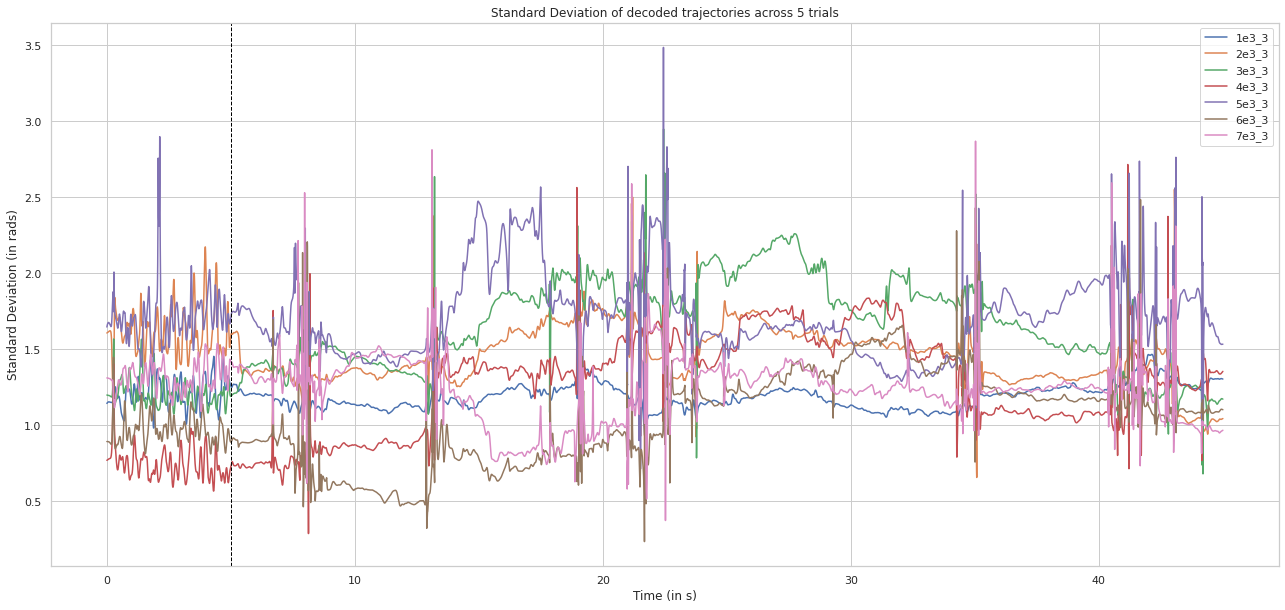

In [121]:
g_utils.plot_mult_stddev(sim_id_list=['1e3_3','2e3_3','3e3_3','4e3_3','5e3_3','6e3_3','7e3_3'],sim_num=0,num_trials=5,allo_time=5,save="figs_poster/stdev_poster")

num_trials :  5
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
Number of trials: 5
[2.49986607e-11 4.99964287e-11 7.49933038e-11 ... 5.25549528e-01
 5.25788635e-01 5.26029618e-01]
Top-level groups: ['0', '1', '2', '3', '4']
0 contains: ['stell_spks']
1 contains: ['stell_spks']
2 contains: ['stell_spks']
3 contains: ['stell_spks']
4 contains: ['stell_spks']
Trial Number  0
Hallelujah
Stellate File Path :  data/1e3_2/stell_spks_1e3_2.hdf5
Interneuron File Path :  data/1e3_2/intrnrn_spks_1e3_2.hdf5
Trial Number  1
Hallelujah
Stellate File Path :  data/1e3_2/stell_spks_1e3_2.hdf5
Interneuron File Path :  data/1e3_2/intrnrn_spks_1e3_2.hdf5
Trial Number  2
Hallelujah
Stellate File Path :  data/1e3_2/stell_spks_1e3_2.hdf5
Interneuron File Path :  data/1e3_2/intrnrn_spks_1e3_2.hdf5
Trial Number  3
Hallelujah
Stellate File Path :  data/1e3_2/stell_spks_1e3_2.hdf5
Interneuron File Path :  data/1e3_2/intrnrn_spks_1e3_2.hdf5
Trial Number  4
Hallelu

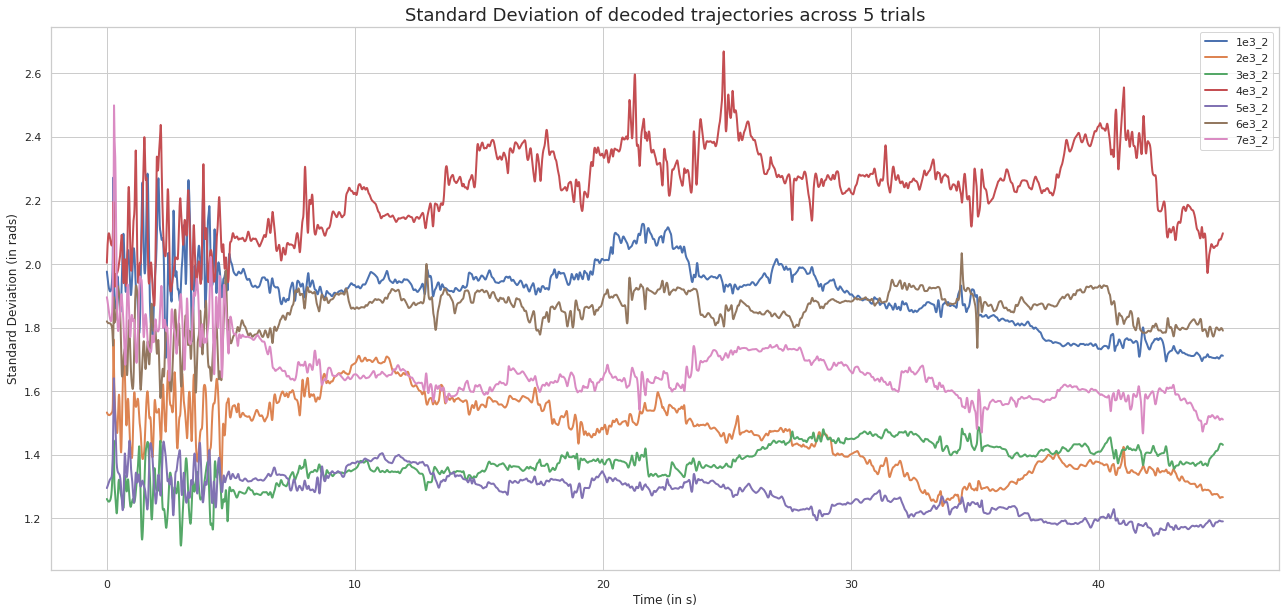

In [103]:
g_utils.plot_mult_stddev(sim_id_list=['1e3_2','2e3_2','3e3_2','4e3_2','5e3_2','6e3_2','7e3_2'],sim_num=0,num_trials=5)